# Lab 6: APOGEE Stellar Spectra - Bayesian Linear Regression

**Name:** [Your Name Here]  
**Date:** [Date]

**Keywords:** Bayesian Linear Regression, Error Propagation, Posterior Distribution, Uncertainty Quantification

## Introduction

In this lab, we explore Bayesian linear regression using APOGEE stellar spectra data. We'll learn how to:
- Properly quantify prediction uncertainties
- Understand why naive MLE error estimates fail
- Implement Bayesian linear regression with heteroscedastic noise
- Make predictions with full uncertainty quantification
- Evaluate model calibration using coverage statistics

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Configure plotting parameters
plt.rcParams['figure.figsize'] = [10, 10]
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20

# Set random seed for reproducibility
np.random.seed(42)

%matplotlib inline

## Part 1: Loading and Preparing Dataset

### Background
APOGEE (Apache Point Observatory Galactic Evolution Experiment) provides high-resolution infrared spectra of stars. Each spectrum contains flux measurements at different wavelengths that encode information about stellar properties including temperature.

### Task 1a: Load Data and Add Heteroscedastic Noise

Load the dataset and add realistic heteroscedastic noise to temperatures:

$$\sigma_{\text{teff}} = 50 + 150 \cdot \frac{T_{\text{eff}} - T_{\text{min}}}{T_{\text{max}} - T_{\text{min}}}$$

This creates uncertainties ranging from 50K (coolest stars) to 200K (hottest stars).

In [22]:
# TODO: Load 'dataset_apogee_spectra.npz' and extract arrays
np.random.seed(42)
file = np.load('dataset_apogee_spectra.npz')
spectra = file['spectrum_array']
wavelength = file['wavelength']
teff_array = file['teff_array']
# TODO: Calculate teff_min, teff_max from teff_array
teff_min = np.min(teff_array)
teff_max = np.max(teff_array)
# TODO: Calculate sigma_teff using formula: 50 + 150 * (teff - min)/(max - min)
sigma_teff = 50 + 150 * ((teff_array - teff_min) / (teff_max - teff_min))
# TODO: Create teff_observed = teff_array + np.random.normal(0, sigma_teff)
teff_observed = teff_array + np.random.normal(0, sigma_teff)
# TODO: Print summary statistics

print(f'Teff true: \nmin={teff_observed.min():.3f}, \nmax={teff_observed.max():.3f}, \nmean={teff_observed.mean():.3f}, \nstd={teff_observed.std():.3f}')

Teff true: 
min=3150.645, 
max=7349.616, 
mean=4404.487, 
std=713.961


### Task 1b: Construct Design Matrix

Create design matrix $\boldsymbol{\Phi}$ with:
- Each row = one star (N stars)
- Each column = one spectral feature (M wavelengths)
- Add bias term (column of ones) at the end

**Question:** What is the final dimension of your design matrix?

In [82]:
# TODO: Phi = np.hstack((spectra, np.ones((len(spectra), 1))))
phi = np.hstack((spectra, np.ones((len(spectra), 1))))

# TODO: Print Phi.shape - should be (N, M+1)
print(f' Phi shape: {phi.shape}')

 Phi shape: (3000, 2001)


### Task 1c: Train-Test Split

Split data into 80% training and 20% testing, including uncertainties.

In [28]:
# TODO: n_train = int(0.8 * len(Phi))
n_train = int(0.8 * len(phi))
# TODO: indices = np.random.permutation(len(Phi))
indices = np.random.permutation(len(phi))
# TODO: Split using indices[:n_train] and indices[n_train:]
phi_train = phi[indices[:n_train]]
phi_test = phi[indices[n_train:]]
# TODO: Create Phi_train, Phi_test, t_train, t_test, sigma_train, sigma_test

phi_train = phi[indices[:n_train]]
phi_test = phi[indices[n_train:]]
t_train = teff_observed[indices[:n_train]]
t_test = teff_observed[indices[n_train:]]
sigma_train = sigma_teff[indices[:n_train]]
sigma_test = sigma_teff[indices[n_train:]]


### Task 1d: Visualize Spectra

Plot all spectra color-coded by temperature with a colorbar.

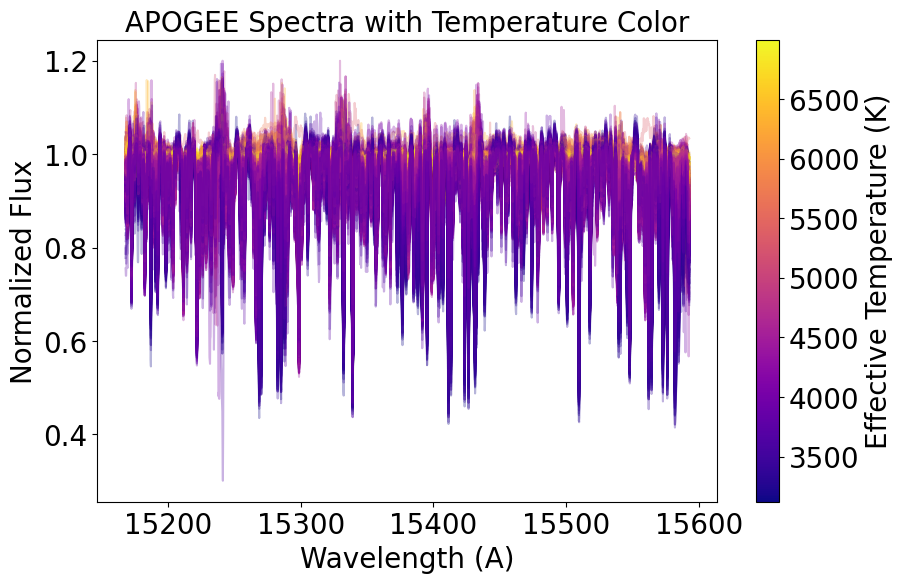

In [32]:
# TODO: colors = plt.cm.plasma((teff_array - teff_min) / (teff_max - teff_min))
# TODO: Loop: ax.plot(wavelength, spectra[i], color=colors[i], alpha=0.3)
# TODO: Add colorbar with ScalarMappable
# TODO: Set labels and show

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.plasma((teff_array - teff_min) / (teff_max - teff_min))

for i in range(len(spectra)):
    ax.plot(wavelength, spectra[i], color = colors[i], alpha=0.3)
colorbar = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=teff_min, vmax=teff_max))
fig.colorbar(colorbar, ax=ax, label='Effective Temperature (K)')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('Normalized Flux')
ax.set_title('APOGEE Spectra with Temperature Color');

## Part 2: MLE Error Estimates

### Background
The maximum likelihood solution for linear regression is:

$$\mathbf{w}_{\text{ML}} = (\boldsymbol{\Phi}^T\boldsymbol{\Phi})^{-1}\boldsymbol{\Phi}^T\mathbf{t}$$

### Task 2a: Compute MLE and Naive Uncertainty Estimates

Implement the MLE solution and compute RMSE on training and test sets:

$$\sigma_{\text{naive}} = \sqrt{\frac{1}{N}\sum_{n=1}^N(t_n - \mathbf{w}_{\text{ML}}^T\boldsymbol{\phi}_n)^2}$$

In [41]:
# TODO: Define fit_naive_mle(Phi_train, t_train, Phi_test, t_test)
def fit_naive_mle(Phi_train, t_train, Phi_test, t_test):
    w_ml = np.linalg.inv(Phi_train.T @ Phi_train) @ Phi_train.T @ t_train
# TODO: w_ml = np.linalg.inv(Phi_train.T @ Phi_train) @ Phi_train.T @ t_train
# TODO: pred_train = Phi_train @ w_ml, pred_test = Phi_test @ w_ml
    pred_train = Phi_train @ w_ml
    pred_test = Phi_test @ w_ml
# TODO: sigma_mle = sqrt(mean((t_train - pred_train)^2))
    sigma_mle = np.sqrt(np.mean((t_train - pred_train) ** 2))
# TODO: rmse_test = sqrt(mean((t_test - pred_test)^2))
    rmse_test = np.sqrt(np.mean((t_test - pred_test) ** 2))
# TODO: Call function and print ratio rmse_test/sigma_mle
    print(f'RMSE test / sigma_mle: {rmse_test / sigma_mle:.3f}')
    
rmse_ratio = fit_naive_mle(phi_train, t_train, phi_test, t_test)


 

RMSE test / sigma_mle: 9.444


### Task 2b: Visualize Residuals

Create two plots:
1. Histogram of training vs test residuals with Gaussian fits
2. Histogram of normalized test residuals compared to N(0,1)

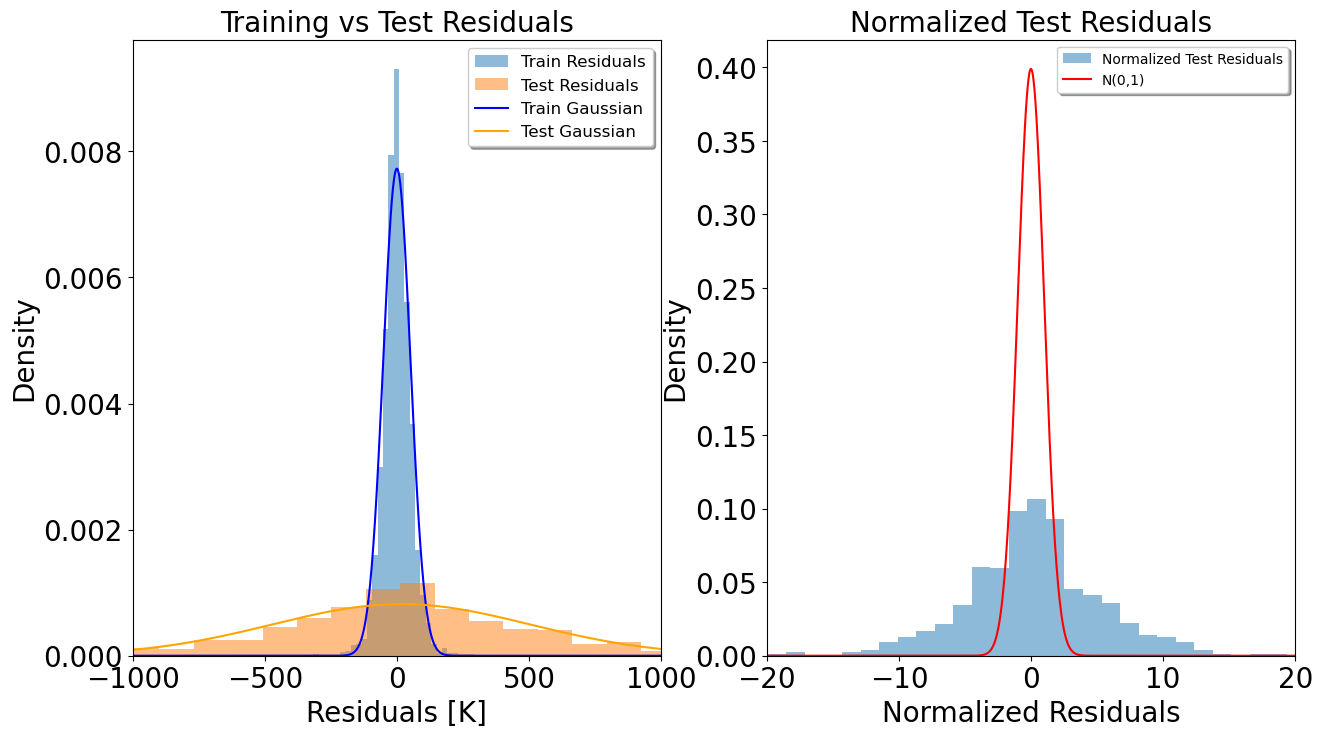

In [68]:
# TODO: Create 2 subplots (1,2)
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
# TODO: Left: histogram of residuals_train and residuals_test with Gaussian overlays

residuals_train = t_train - (phi_train @ (np.linalg.inv(phi_train.T @ phi_train) @ phi_train.T @ t_train))
residuals_test = t_test - (phi_test @ (np.linalg.inv(phi_train.T @ phi_train) @ phi_train.T @ t_train))

# Plot histograms
axes[0].hist(residuals_train, bins=30, density=True, alpha=0.5, label='Train Residuals');
axes[0].hist(residuals_test, bins=30, density=True, alpha=0.5, label='Test Residuals');
x = np.linspace(-1000, 1000, 1000)
mu_train, std_train = np.mean(residuals_train), np.std(residuals_train)
mu_test, std_test = np.mean(residuals_test), np.std(residuals_test)

#Plot gaussian overlays
axes[0].plot(x, 1/(std_train * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu_train)/std_train)**2), label='Train Gaussian', color='blue')
axes[0].plot(x, 1/(std_test * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu_test)/std_test)**2), label='Test Gaussian', color='orange')

#set plot limits and labels
axes[0].set_xlim(-1000, 1000)
axes[0].set_xlabel('Residuals [K]')
axes[0].set_ylabel('Density')
axes[0].set_title('Training vs Test Residuals')
axes[0].legend(shadow=True, fontsize=12);

# TODO: Right: histogram of (residuals_test / sigma_test) vs N(0,1)

axes[1].hist(residuals_test / sigma_test, bins=30, density=True, alpha=0.5, label='Normalized Test Residuals');
# Plot N(0,1) overlay
x_norm = np.linspace(-20, 20, 1000)
axes[1].plot(x_norm, 1/np.sqrt(2 * np.pi) * np.exp(-0.5 * x_norm**2), label='N(0,1)', color='red')

#set plot limits and labels
axes[1].set_xlim(-20, 20)
axes[1].set_xlabel('Normalized Residuals')
axes[1].set_ylabel('Density')
axes[1].set_title('Normalized Test Residuals')
axes[1].legend(shadow=True, fontsize=10,loc='upper right');
# TODO: Show that normalized residuals have std >> 1.0

**Question:** What do these plots tell us about the naive MLE approach? Why is the normalized residual distribution wider than expected?
The naive MlE approach 

## Part 3: Bayesian Linear Regression

### Background
Bayesian linear regression computes a posterior distribution:

$$p(\mathbf{w}|\mathbf{t}, \boldsymbol{\Phi}, \boldsymbol{\Sigma}) = \mathcal{N}(\mathbf{w}|\mathbf{m}_N, \mathbf{S}_N)$$

where:
- $\mathbf{S}_N = (\mathbf{S}_0^{-1} + \boldsymbol{\Phi}^T\boldsymbol{\Sigma}^{-1}\boldsymbol{\Phi})^{-1}$ (posterior covariance)
- $\mathbf{m}_N = \mathbf{S}_N(\boldsymbol{\Phi}^T\boldsymbol{\Sigma}^{-1}\mathbf{t})$ (posterior mean)
- $\mathbf{S}_0 = \eta^2\mathbf{I}$ (prior covariance)
- $\boldsymbol{\Sigma} = \text{diag}(\sigma_1^2, ..., \sigma_N^2)$ (measurement covariance)

### Task 3a: Compute Posterior Distribution

Implement the posterior computation for different prior strengths $\eta^2$ = [1000, 100000, 10000000].

In [105]:
# TODO: Define compute_posterior(Phi, t, sigma, eta2)
def compute_posterior(Phi, t, sigma, eta2):
    M = Phi.shape[1]
    S0_inv = np.eye(M) / eta2
    Sigma_inv = np.diag(1 / sigma**2)
    S_N = np.linalg.inv(S0_inv + Phi.T @ Sigma_inv @ Phi)
    m_N = S_N @ (Phi.T @ Sigma_inv @ t)
    return m_N, S_N


# TODO: S0_inv = np.eye(M) / eta2
# TODO: Sigma_inv = np.diag(1 / sigma**2)
# TODO: S_N = np.linalg.inv(S0_inv + Phi.T @ Sigma_inv @ Phi)
# TODO: m_N = S_N @ (Phi.T @ Sigma_inv @ t)
# TODO: Loop eta2_values=[1e3, 1e5, 1e7], compute posteriors
eta2_values = [1e3, 1e5, 1e7]
posteriors = []
for eta2 in eta2_values:
    m_N, S_N = compute_posterior(phi_train, t_train, sigma_train, eta2)
    posteriors.append((m_N, S_N))
    print(f'For eta2 = {eta2}:')
    print(f'm_N (first 4 elements) = {m_N[:4]}')
    
    
    
   # mn and sn are weights and covariance matrix of weights 
   # weights will have the shape of the spectra
   # weight per wavelength point
    

    

For eta2 = 1000.0:
m_N (first 4 elements) = [77.02878937 40.62564099 24.28654306 34.23374602]
For eta2 = 100000.0:
m_N (first 4 elements) = [ 240.44262837 -181.77062669 -337.64936081  229.44688875]
For eta2 = 10000000.0:
m_N (first 4 elements) = [   30.12541189 -1903.9965183  -1788.72873746   485.67898907]


**Questions:** 
- What do $\mathbf{m}_N$ and $\mathbf{S}_N$ represent?

- How does this compare to the naive MLE weights $\mathbf{w}_{\text{ML}}$?

### Task 3b: Visualize Spectral Weights

Plot the spectral weights with uncertainty bands (±2σ) for each prior strength.

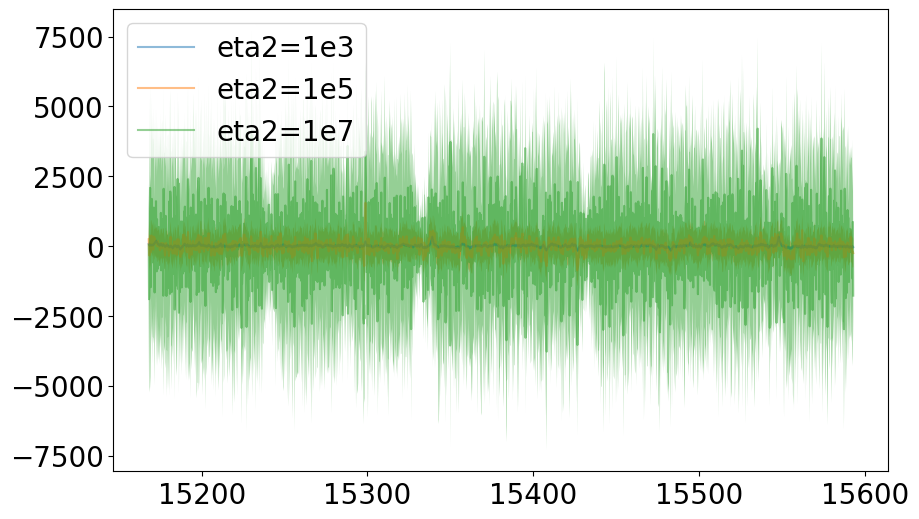

In [184]:
# TODO: Loop posteriors: spectral_weights = m_N[:-1]
spectral_weights = []
weight_stds = []
for m_N, S_N in posteriors:
    spectral_weights.append(m_N[:-1])
    

# TODO: weight_std = np.sqrt(np.diag(S_N[:-1, :-1]))
    weight_std = np.sqrt(np.diag(S_N[:-1, :-1]))
    weight_stds.append(weight_std)

# TODO: plt.plot(wavelength, spectral_weights)
fig, ax = plt.subplots(figsize=(10, 6))
std = weight_stds

ax.plot(wavelength, spectral_weights[0], alpha=0.5, label='eta2=1e3')
ax.plot(wavelength, spectral_weights[1], alpha=0.5, label='eta2=1e5')
ax.plot(wavelength, spectral_weights[2], alpha=0.5, label='eta2=1e7')
ax.fill_between(wavelength, spectral_weights[0] - 2*std[0], spectral_weights[0] + 2*std[0], alpha=0.5)
ax.fill_between(wavelength, spectral_weights[1] - 2*std[1], spectral_weights[1] + 2*std[1], alpha=0.5)
ax.fill_between(wavelength, spectral_weights[2] - 2*std[2], spectral_weights[2] + 2*std[2], alpha=0.5)
ax.legend()
# TODO: plt.fill_between(wavelength, weights-2*std, weights+2*std, alpha=0.2)

**Question:** Which $\eta^2$ provides the optimal balance? Why?

## Part 4: Making Bayesian Predictions with Uncertainty

### Background
The predictive distribution is:

$$p(t_*|\boldsymbol{\phi}_*, \mathcal{D}) = \mathcal{N}(t_*|\mu_*, \sigma_*^2)$$

with:
- Mean: $\mu_* = \mathbf{m}_N^T\boldsymbol{\phi}_*$
- Variance: $\sigma_*^2 = \sigma_{\text{obs},*}^2 + \boldsymbol{\phi}_*^T\mathbf{S}_N\boldsymbol{\phi}_* + \sigma_{\text{model}}^2$

### Task 4a: Implement Prediction Function

In [181]:
# TODO: Define predict_with_uncertainty(Phi_new, sigma_new, m_N, S_N, sigma_model)
def predict_with_uncertainty(Phi_new, sigma_new, m_N, S_N, sigma_model):
# TODO: pred_mean = Phi_new @ m_N
    pred_mean = Phi_new @ m_N
# TODO: param_var = np.sum(Phi_new @ S_N * Phi_new, axis=1)
    param_var = np.sum(Phi_new @ S_N * Phi_new, axis=1)
# TODO: pred_var = param_var + sigma_new**2 + sigma_model**2
    pred_var = param_var + sigma_new**2 + sigma_model**2
    
# TODO: Return pred_mean, np.sqrt(pred_var)
    return pred_mean, np.sqrt(pred_var)

### Task 4b: Visualize Predictions with Uncertainties

Plot predicted vs true temperatures with uncertainty bands.

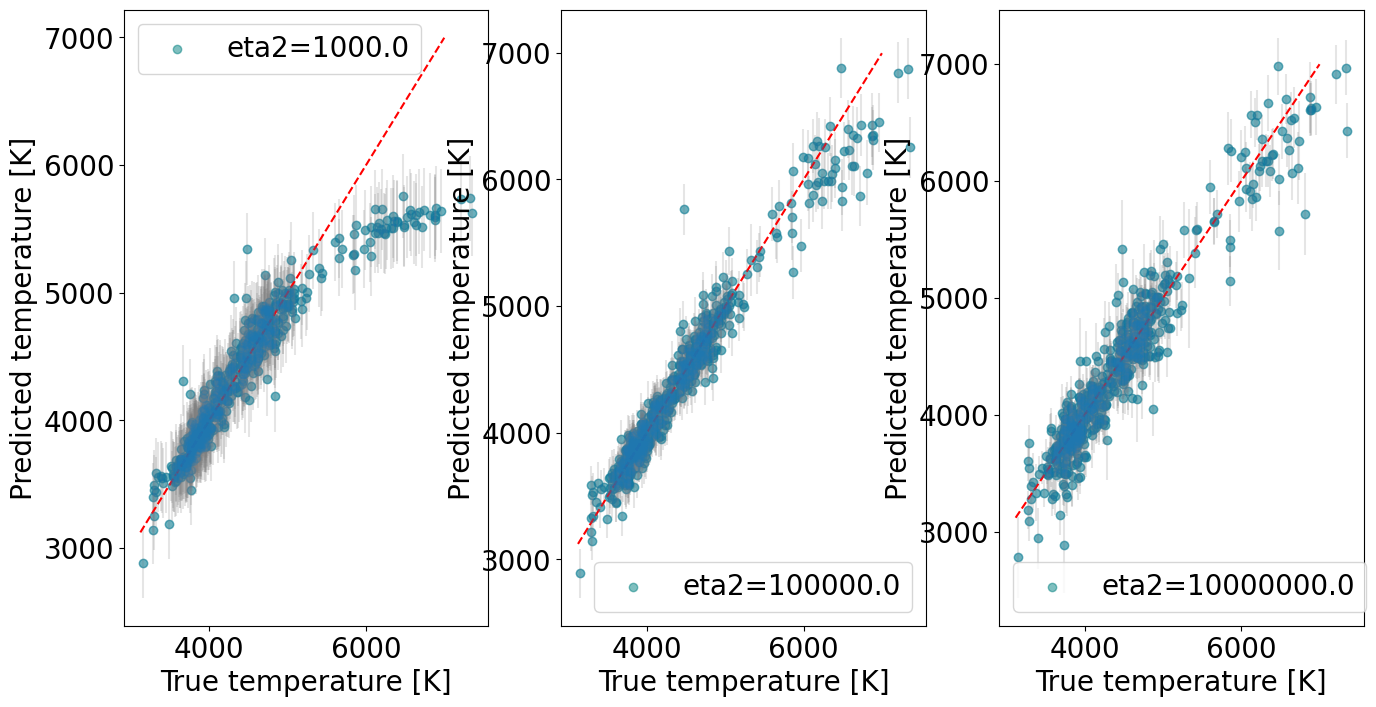

In [182]:
# TODO: Loop posteriors, get pred_mean and pred_std
# TODO: plt.scatter(t_test, pred_mean), add y=x line
# TODO: rmse = np.sqrt(np.mean((t_test - pred_mean)**2))
# TODO: z_scores = (t_test - pred_mean) / pred_std
# TODO: coverage = np.mean(np.abs(z_scores) < 2)

fig, ax = plt.subplots(1,3,figsize=(16, 8))
for i, (m_N, S_N) in enumerate(posteriors):
    sigma_model = np.sqrt(np.mean((t_train - (phi_train @ m_N))**2))
    pred_mean, pred_std = predict_with_uncertainty(phi_test, sigma_test, m_N, S_N, sigma_model)
    ax[i].scatter(t_test, pred_mean, alpha=0.5,color = 'teal', label=f'eta2={eta2_values[i]}')
    ax[i].errorbar(t_test, pred_mean, yerr=pred_std, fmt='o', alpha=0.2, ecolor='gray')
    rmse = np.sqrt(np.mean((t_test - pred_mean)**2))
    z_scores = (t_test - pred_mean) / pred_std
    coverage = np.mean(np.abs(z_scores) < 2)
    ax[i].set_xlabel('True temperature [K]')
    ax[i].set_ylabel('Predicted temperature [K]')
    ax[i].set_title(f'')
    ax[i].plot([teff_min, teff_max],[teff_min, teff_max], color='red', linestyle='--')
    ax[i].legend()


### Task 4c: Calculate Coverage

Compute the 95% coverage using Z-scores:

$$z = \frac{t_{\text{true}} - t_{\text{predicted}}}{\sigma_{\text{predicted}}}$$

For well-calibrated uncertainties, ~95% of z-scores should have |z| < 2.

In [185]:
# TODO: Loop posteriors
for i, (m_N, S_N) in enumerate(posteriors):
    sigma_model = np.sqrt(np.mean((t_train - (phi_train @ m_N))**2))
    pred_mean, pred_std = predict_with_uncertainty(phi_test, sigma_test, m_N, S_N, sigma_model)
    rmse = np.sqrt(np.mean((t_test - pred_mean)**2))
    z_scores = (t_test - pred_mean) / pred_std
    coverage = np.mean(np.abs(z_scores) < 2)
    eta2 = eta2_values[i]
    print(f"η²={eta2:.0e}: RMSE={rmse:.1f}K, Coverage={coverage:.3f}")
# TODO: Get predictions, calculate z_scores and coverage

# TODO: Print f"η²={eta2:.0e}: RMSE={rmse:.1f}K, Coverage={coverage:.3f}""

η²=1e+03: RMSE=294.8K, Coverage=0.930
η²=1e+05: RMSE=166.4K, Coverage=0.967
η²=1e+07: RMSE=220.4K, Coverage=0.933


**Questions:**
- Which prior gives the best coverage?
- What does coverage < 0.95 indicate?
- What does coverage > 0.95 indicate?

## Bonus: Visualize Z-score Distribution

### Task 4d: Plot Z-scores

Compare the z-score distribution to the expected N(0,1).

In [ ]:
# TODO: m_N_opt, S_N_opt = posteriors[1]  # eta2=1e5
# TODO: Get predictions and z_scores = (t_test - pred_mean) / pred_std
# TODO: plt.hist(z_scores), overlay (1/sqrt(2π)) * exp(-x²/2)
# TODO: Print mean and std of z_scores (should be ~0 and ~1)

**Question:** Are your uncertainties well-calibrated? How can you tell?

## Summary and Conclusions

**Key Takeaways:**

1. **Naive MLE fails:** Training RMSE severely underestimates prediction uncertainty due to overfitting

2. **Bayesian approach:** Properly accounts for parameter uncertainty, measurement noise, and model inadequacy

3. **Prior selection:** The prior strength $\eta^2$ controls the balance between flexibility and regularization

4. **Calibration matters:** Well-calibrated uncertainties are essential for scientific inference

5. **Uncertainty decomposition:** Understanding different sources of error helps guide improvement efforts

**Your findings:**

[Write your conclusions here - which prior was optimal? What was the final RMSE and coverage?]